# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP PROJECT

### Project Name - Restaurant Insights Enhancement 
### Project Type - EDA
### Intern Name - Aditi Ganpat Khade 

# Level 2 Tasks :-

## ******************************* Import Libraries *******************************

In [49]:
# Importing Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib
%matplotlib inline
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Ignore all warnings
import warnings
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## ******************************* Loading Dataset *******************************

In [25]:
# Load Dataset from github repository
df = pd.read_csv(r'C:\Users\Administrator\Desktop\Cognifyz Technologies\Project\Dataset .csv')

# ═══════════════════════════════════════════════════
# LEVEL 2 │ TASK 1 – Table Booking & Online Delivery
# ═══════════════════════════════════════════════════

In [29]:
# Convert Yes/No to 1/0
df['Has Table booking'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

# Total restaurants
total = len(df)

# Percentage calculation
tb_count = df['Has Table booking'].sum()
od_count = df['Has Online delivery'].sum()

tb_pct = (tb_count / total) * 100
od_pct = (od_count / total) * 100

print(f"\n🪑 Restaurants offering Table Booking : {tb_count} ({tb_pct:.1f}%)")
print(f"🛵 Restaurants offering Online Delivery: {od_count} ({od_pct:.1f}%)")


🪑 Restaurants offering Table Booking : 1158 (12.1%)
🛵 Restaurants offering Online Delivery: 2451 (25.7%)


In [31]:
# Keep only valid ratings
rated_df = df[df['Aggregate rating'] > 0].copy()

# Average ratings
tb_yes = rated_df[rated_df['Has Table booking'] == 1]['Aggregate rating'].mean()
tb_no  = rated_df[rated_df['Has Table booking'] == 0]['Aggregate rating'].mean()

od_yes = rated_df[rated_df['Has Online delivery'] == 1]['Aggregate rating'].mean()
od_no  = rated_df[rated_df['Has Online delivery'] == 0]['Aggregate rating'].mean()

print("\n⭐ Average Rating Comparison")
print("---------------------------------------")
print(f"With Table Booking     : {tb_yes:.3f}")
print(f"Without Table Booking  : {tb_no:.3f}")
print(f"With Online Delivery   : {od_yes:.3f}")
print(f"Without Online Delivery: {od_no:.3f}")


⭐ Average Rating Comparison
---------------------------------------
With Table Booking     : 3.588
Without Table Booking  : 3.414
With Online Delivery   : 3.381
Without Online Delivery: 3.467


In [33]:
# Convert Yes/No to 1/0 (only if needed)
if df['Has Online delivery'].dtype == 'object':
    df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

print("\n📦 Online Delivery Availability by Price Range:")

od_price = df.groupby('Price range')['Has Online delivery'].agg(['sum', 'count'])
od_price['%_with_delivery'] = (od_price['sum'] / od_price['count'] * 100).round(2)

# Rename price range labels safely
price_labels = {
    1: 'Budget (1)',
    2: 'Mid-Range (2)',
    3: 'Premium (3)',
    4: 'Luxury (4)'
}

od_price.index = od_price.index.map(price_labels)

print(od_price.to_string())


📦 Online Delivery Availability by Price Range:
                sum  count  %_with_delivery
Price range                                
Budget (1)      701   4444            15.77
Mid-Range (2)  1286   3113            41.31
Premium (3)     411   1408            29.19
Luxury (4)       53    586             9.04


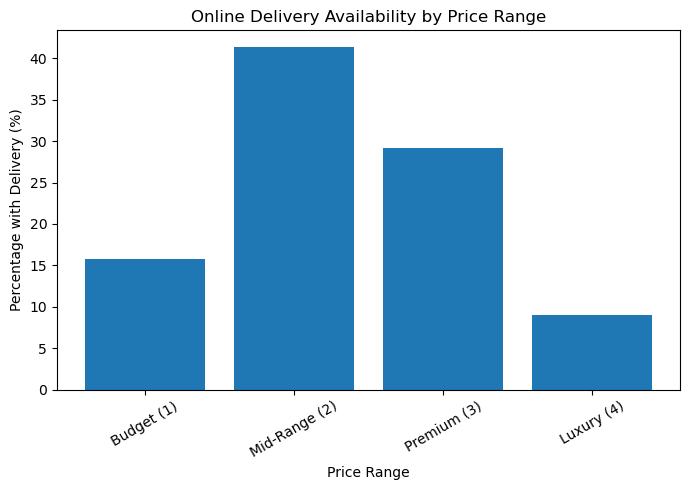

In [53]:
plt.figure(figsize=(7,5))

plt.bar(od_price.index.astype(str), od_price['%_with_delivery'])

plt.title('Online Delivery Availability by Price Range')
plt.ylabel('Percentage with Delivery (%)')
plt.xlabel('Price Range')

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

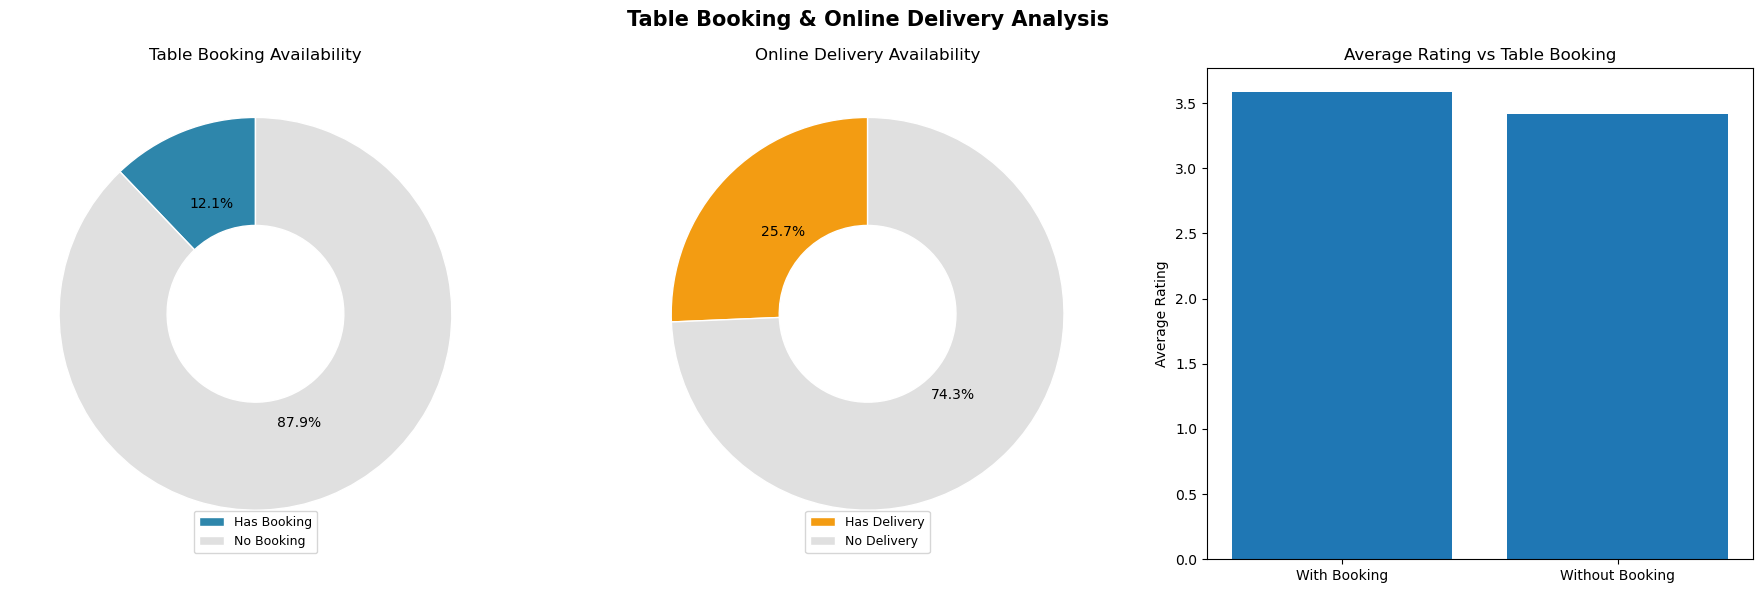

In [57]:
import matplotlib.pyplot as plt

# Ensure binary format (only if needed)
if df['Has Table booking'].dtype == 'object':
    df['Has Table booking'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
    df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

total = len(df)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Table Booking & Online Delivery Analysis',fontsize=15, fontweight='bold')

# -----------------------------
# 1️⃣ Donut Chart – Table Booking
# -----------------------------
tb_vals = [ df['Has Table booking'].sum(), total - df['Has Table booking'].sum()]

axes[0].pie( tb_vals, autopct='%1.1f%%', startangle=90,colors=['#2E86AB', '#E0E0E0'], wedgeprops=dict(width=0.55, edgecolor='white'))
axes[0].set_title('Table Booking Availability')
axes[0].legend(['Has Booking', 'No Booking'], loc='lower center', fontsize=9)

# -----------------------------
# 2️⃣ Donut Chart – Online Delivery
# -----------------------------
od_vals = [ df['Has Online delivery'].sum(), total - df['Has Online delivery'].sum()]

axes[1].pie( od_vals, autopct='%1.1f%%', startangle=90, colors=['#F39C12', '#E0E0E0'],wedgeprops=dict(width=0.55, edgecolor='white'))
axes[1].set_title('Online Delivery Availability')
axes[1].legend(['Has Delivery', 'No Delivery'], loc='lower center', fontsize=9)

# -----------------------------
# 3️⃣ Bar Chart – Avg Rating Comparison
# -----------------------------
rated_df = df[df['Aggregate rating'] > 0]

tb_yes = rated_df[rated_df['Has Table booking'] == 1]['Aggregate rating'].mean()
tb_no  = rated_df[rated_df['Has Table booking'] == 0]['Aggregate rating'].mean()

axes[2].bar(['With Booking', 'Without Booking'], [tb_yes, tb_no])
axes[2].set_title('Average Rating vs Table Booking')
axes[2].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════════
# LEVEL 2 │ TASK 2 – Price Range Analysis
# ═════════════════════════════════════════════════

In [63]:
print("\n💰 Price Range Distribution:")

for pr, cnt in price_counts.items():
    label = price_labels.get(pr, 'Unknown')
    percentage = (cnt / total) * 100
    print(f"   Range {pr} ({label:10s}): {cnt:4d} restaurants ({percentage:.1f}%)")

# Most common price range
most_common_pr = price_counts.idxmax()
most_common_label = price_labels.get(most_common_pr, 'Unknown')

print(f"\n🏆 Most Common Price Range: {most_common_pr} ({most_common_label})")


💰 Price Range Distribution:
   Range 1 (Budget    ): 4444 restaurants (46.5%)
   Range 2 (Mid-Range ): 3113 restaurants (32.6%)
   Range 3 (Premium   ): 1408 restaurants (14.7%)
   Range 4 (Luxury    ):  586 restaurants (6.1%)

🏆 Most Common Price Range: 1 (Budget)


In [65]:
rated_df = df[df['Aggregate rating'] > 0].copy()

# Group by price range
avg_rating_pr = ( rated_df.groupby('Price range')['Aggregate rating'].mean().round(3))

# Price labels
price_labels = {
    1: 'Budget',
    2: 'Mid-Range',
    3: 'Premium',
    4: 'Luxury'
}

print("\n⭐ Average Rating by Price Range:")

for pr, avg in avg_rating_pr.items():
    label = price_labels.get(pr, 'Unknown')
    print(f"   Range {pr} ({label:10s}): {avg:.3f}")


⭐ Average Rating by Price Range:
   Range 1 (Budget    ): 3.239
   Range 2 (Mid-Range ): 3.377
   Range 3 (Premium   ): 3.777
   Range 4 (Luxury    ): 3.891


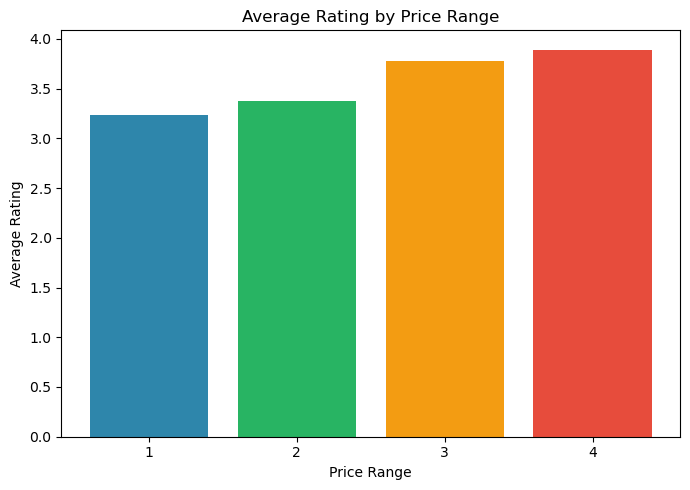

In [71]:
colors = ['#2E86AB', '#28B463', '#F39C12', '#E74C3C']

plt.figure(figsize=(7,5))

plt.bar( avg_rating_pr.index.astype(str),avg_rating_pr.values, color=colors[:len(avg_rating_pr)] )

plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════
# LEVEL 2 │ TASK 3 – Feature Engineering
# ════════════════════════════════════════════════════

In [75]:
# Text-based features 
df['Restaurant Name Length'] = df['Restaurant Name'].fillna('').astype(str).str.len()
df['Address Length'] = df['Address'].fillna('').astype(str).str.len()
df['Locality Name Length'] = df['Locality'].fillna('').astype(str).str.len()

# Cuisine count (handle NaN properly)
df['Cuisine Count'] = ( df['Cuisines'].fillna('').apply(lambda x: len([c for c in str(x).split(',') if c.strip() != ''])))

# Multi-cuisine flag
df['Is Multi-Cuisine'] = (df['Cuisine Count'] > 1).astype(int)

# High rating flag
df['Has High Rating'] = (df['Aggregate rating'].fillna(0) >= 4.0).astype(int)

In [77]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Aggregate rating,Rating color,Rating text,Votes,Restaurant Name Length,Address Length,Locality Name Length,Cuisine Count,Is Multi-Cuisine,Has High Rating
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,4.8,Dark Green,Excellent,314,16,71,41,3,1,1
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,4.5,Dark Green,Excellent,591,16,67,42,1,0,1
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,4.4,Green,Very Good,270,22,56,42,4,1,1
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,4.9,Dark Green,Excellent,365,4,70,38,2,1,1
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,4.8,Dark Green,Excellent,229,11,64,38,2,1,1


In [81]:
print("\n🔗 Correlation of New Features with Aggregate Rating:")
new_feats = ['Restaurant Name Length','Address Length','Cuisine Count',
             'Is Multi-Cuisine','Has High Rating','Locality Name Length']

# Ensure required columns are numeric
binary_cols = ['Has Table booking', 'Has Online delivery']

for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Yes':1, 'No':0})

# Feature list
corr_feats = new_feats + ['Has Table booking', 'Has Online delivery', 'Price range']

# Compute correlation
corr_with_rating = (df[corr_feats + ['Aggregate rating']].corr(numeric_only=True)['Aggregate rating'].drop('Aggregate rating'))
print(corr_with_rating.sort_values(ascending=False).round(4).to_string())


🔗 Correlation of New Features with Aggregate Rating:
Price range               0.4379
Has High Rating           0.4361
Cuisine Count             0.2484
Has Online delivery       0.2257
Is Multi-Cuisine          0.2117
Has Table booking         0.1900
Locality Name Length      0.1440
Address Length            0.0023
Restaurant Name Length   -0.0352


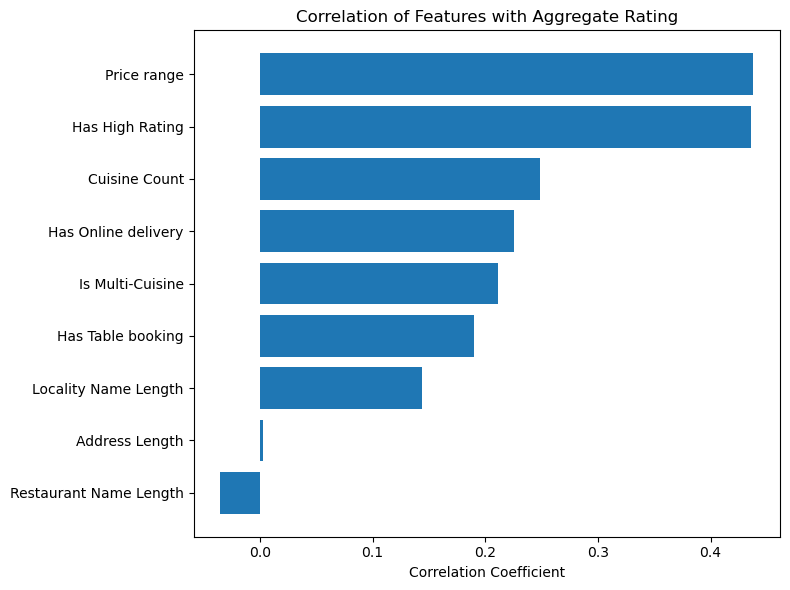

In [83]:
corr_sorted = corr_with_rating.sort_values()

plt.figure(figsize=(8,6))
plt.barh(corr_sorted.index, corr_sorted.values)

plt.title('Correlation of Features with Aggregate Rating')
plt.xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()